<a href="https://colab.research.google.com/github/norayyh/AutoInsight-R/blob/main/autoinsight_haiku.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install anthropic pandas matplotlib

In [11]:
# Upload datasets to Colab from GitHub
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/Iris.csv -O Iris.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/titanic.csv -O titanic.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/housing.csv -O housing.csv
print("Datasets downloaded successfully")

Datasets downloaded successfully


In [12]:
# Install the Anthropic library
import anthropic
from google.colab import userdata

# Initialize the client using the secret API key
client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))

# Send a test request to verify the API connection
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Write Python code using pandas to read iris.csv and print the first 5 rows"}
    ]
)

print(response.content[0].text)

## Reading Iris Dataset with Pandas

```python
import pandas as pd

# Read the CSV file
df = pd.read_csv('iris.csv')

# Print the first 5 rows
print(df.head())
```

### Example Output:
```
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
```

### Alternative: Load directly from seaborn (no CSV needed)
```python
import pandas as pd
import seaborn as sns

# Load built-in iris dataset
df = sns.load_dataset('iris')

# Print the first 5 rows
print(df.head())
```

### Key Notes:
| Method | Description |
|--------|-------------|
| `pd.read_csv('iris.csv')` | Reads a local CSV file |
| `df.head()` | Returns first **5** rows by default |
| `df.head(n)` | Returns fir

In [13]:
import traceback

def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()

# Test the executor with a simple example
test_code = "print('Executor is working!')"
success, message = execute_code(test_code)
print(message)

Executor is working!
Code executed successfully


In [14]:
import re
import pandas as pd
import traceback

def clean_code(code: str) -> str:
    """
    Remove markdown code block formatting from generated code.
    """
    code = re.sub(r"```python\n", "", code)
    code = re.sub(r"```", "", code)
    return code.strip()


def diagnose_error(error_message: str, dataset_path: str) -> str:
    """
    Diagnose the error type and return additional context for repair.
    """
    extra_context = ""

    try:
        df = pd.read_csv(dataset_path)

        if "KeyError" in error_message or "Column not found" in error_message:
            extra_context = f"Actual column names are: {df.columns.tolist()}"

        elif "FileNotFoundError" in error_message:
            extra_context = f"The correct file path is: {dataset_path}"

        elif "TypeError" in error_message or "ValueError" in error_message:
            extra_context = f"Column data types are: {df.dtypes.to_dict()}"

    except Exception:
        pass

    return extra_context


def generate_code(user_request: str, dataset_path: str) -> str:
    """
    Send a request to Claude to generate Python code for data analysis.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
Write Python code to complete the following task: {user_request}
Only return the Python code, no explanations or markdown formatting.
Only use these libraries: pandas, numpy, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def repair_code(user_request: str, previous_code: str, error_message: str, dataset_path: str) -> str:
    """
    Send the failed code and error message back to Claude for repair.
    Uses diagnose_error to inject additional context based on error type.
    """
    extra_context = diagnose_error(error_message, dataset_path)

    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
The user request was: {user_request}

The following code was generated but failed:
{previous_code}

The error message was:
{error_message}
{f"Additional context: {extra_context}" if extra_context else ""}

Please fix the code. Only return the corrected Python code, no explanations or markdown formatting.
Only use these libraries: pandas, numpy, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()


def run_pipeline(user_request: str, dataset_path: str, max_retries: int = 3) -> dict:
    """
    Run the full self-healing pipeline:
    generate code -> execute -> repair if failed -> retry.
    If successful, print the result and final code.
    If all attempts fail, print the error and failed code.
    """
    code = clean_code(generate_code(user_request, dataset_path))

    for attempt in range(max_retries):
        success, message = execute_code(code)

        if success:
            print(f"Success on attempt {attempt + 1}")
            print("\n----- Final Code -----")
            print(code)
            return {"success": True, "attempts": attempt + 1, "code": code}

        print(f"Attempt {attempt + 1} failed.")
        print("----- Error Message -----")
        print(message)

        if attempt < max_retries - 1:
            code = clean_code(repair_code(user_request, code, message, dataset_path))

    print("\n----- All attempts failed -----")
    print("----- Final Failed Code -----")
    print(code)
    return {"success": False, "attempts": max_retries, "code": code, "error": message}


# Test the pipeline with an easy task
result = run_pipeline(
    user_request="Calculate the mean, standard deviation, max, and min for each numeric feature",
    dataset_path="Iris.csv"
)
print(result)

First few rows of the dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Statistics for each numeric feature:
                    Mean  Standard Deviation    Max  Min
Id             75.500000           43.445368  150.0  1.0
SepalLengthCm   5.843333            0.828066    7.9  4.3
SepalWidthCm    3.054000            0.433594    4.4  2.0
PetalLengthCm   3.758667            1.764420    6.9  1.0
PetalWidthCm    1.198667            0.763161    2.5  0.1

Mean values:
Id               75.500000
SepalLengthCm     5.843333
SepalWidthCm      3.054000
PetalLengthCm     3.758667
Petal

In [15]:
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
!mkdir -p benchmarks
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
print("Datasets and benchmarks downloaded successfully")

Datasets and benchmarks downloaded successfully



Running task 1: [medium] Using the Titanic dataset, add a Date column by assigning consecutive dates starting from 2018-01-01 to the rows, then extract the month name and year from Date. Output the first 10 rows with Date, month_name, and year.
        Date month_name  year
0 2018-01-01    January  2018
1 2018-01-02    January  2018
2 2018-01-03    January  2018
3 2018-01-04    January  2018
4 2018-01-05    January  2018
5 2018-01-06    January  2018
6 2018-01-07    January  2018
7 2018-01-08    January  2018
8 2018-01-09    January  2018
9 2018-01-10    January  2018
Success on attempt 1

----- Final Code -----
import pandas as pd
from datetime import datetime, timedelta

# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

# Add a Date column with consecutive dates starting from 2018-01-01
start_date = datetime(2018, 1, 1)
df['Date'] = [start_date + timedelta(days=i) for i in range(len(df))]

# Extract month name and year from Date
df['month_name'] = df['Date'].dt.strftime('%

<string>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




        Species  Mean SepalLengthCm  Std SepalLengthCm
    Iris-setosa               5.006           0.352490
Iris-versicolor               5.936           0.516171
 Iris-virginica               6.588           0.635880
Success on attempt 1

----- Final Code -----
import pandas as pd

df = pd.read_csv('Iris.csv')

result = df.groupby('Species')['SepalLengthCm'].agg(['mean', 'std']).reset_index()

result.columns = ['Species', 'Mean SepalLengthCm', 'Std SepalLengthCm']

print(result.to_string(index=False))
Result: Success | Attempts: 1

Running task 4: [medium] Using the housing dataset, select the numeric columns, add one all-zero row and one all-zero column to the numeric DataFrame, then remove all rows and columns whose values sum to zero. Output the shape before and after removing the zero-sum rows and columns.
Original shape: (20640, 9)
Shape after adding zero row and column: (20641, 10)
Final shape after removing zero-sum rows and columns: (20640, 9)
Success on attempt 1

----- Fin

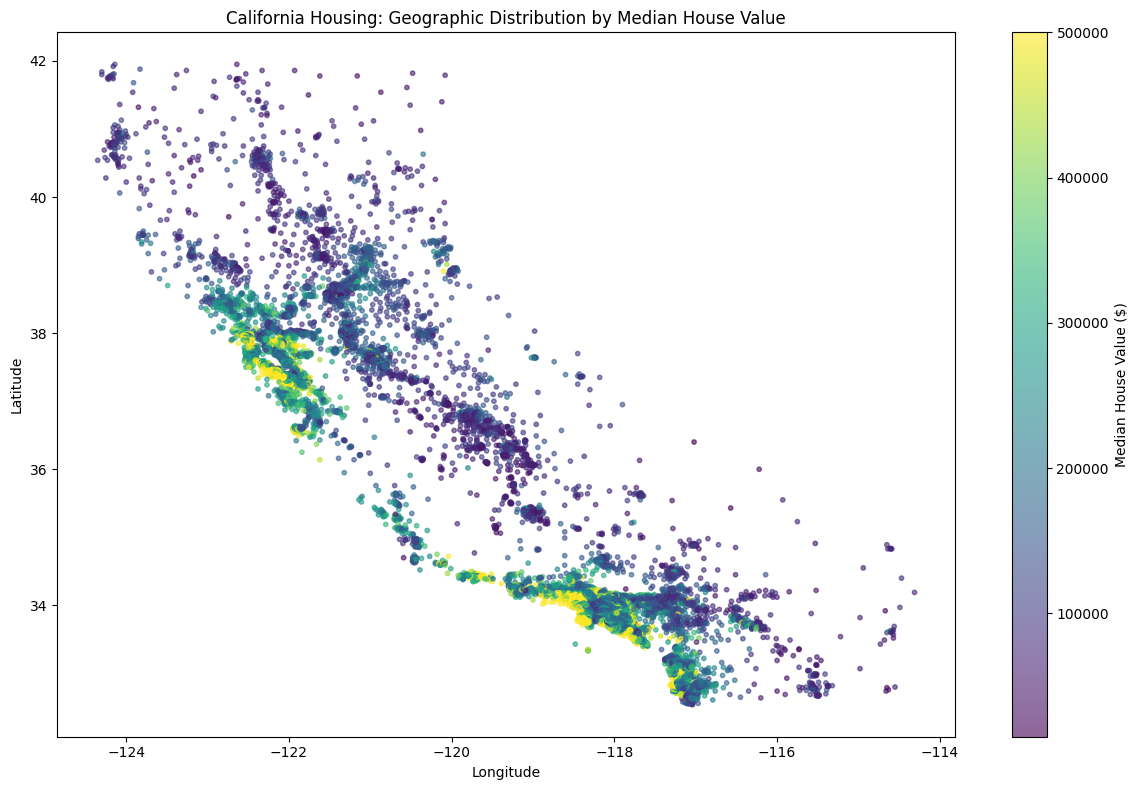

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

# Load the housing dataset
df = pd.read_csv('housing.csv')

# Create a scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create the scatter plot with color representing median_house_value
scatter = ax.scatter(df['longitude'], df['latitude'], 
                     c=df['median_house_value'], 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=10)

# Add labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California Housing: Geographic Distribution by Median House Value')

# Add colorbar
colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label('Median House Value ($)')

# Display the plot
plt.tight_layout()
plt.show()
Result: Success | Attempts: 1

Running task 18: [medium] Using the housing dataset, plot a histogram of median_income and add a solid vertical line at the median value labeled "median income". Sh

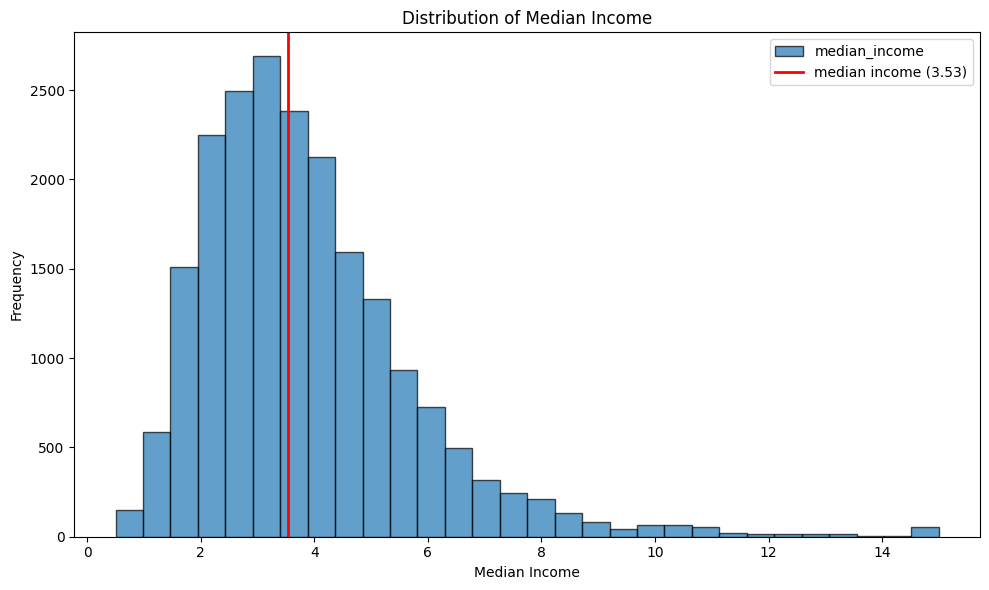

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('housing.csv')

# Calculate the median of median_income
median_value = df['median_income'].median()

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['median_income'], bins=30, edgecolor='black', alpha=0.7, label='median_income')

# Add a vertical line at the median value
plt.axvline(median_value, color='red', linestyle='-', linewidth=2, label=f'median income ({median_value:.2f})')

# Add labels and title
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.title('Distribution of Median Income')

# Show the legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()
Result: Success | Attempts: 1

Running task 19: [medium] Using the housing dataset, compute the correlation matrix for numeric columns and plot it as a heatmap using matplotlib. Add a colorbar and readable tick labels.


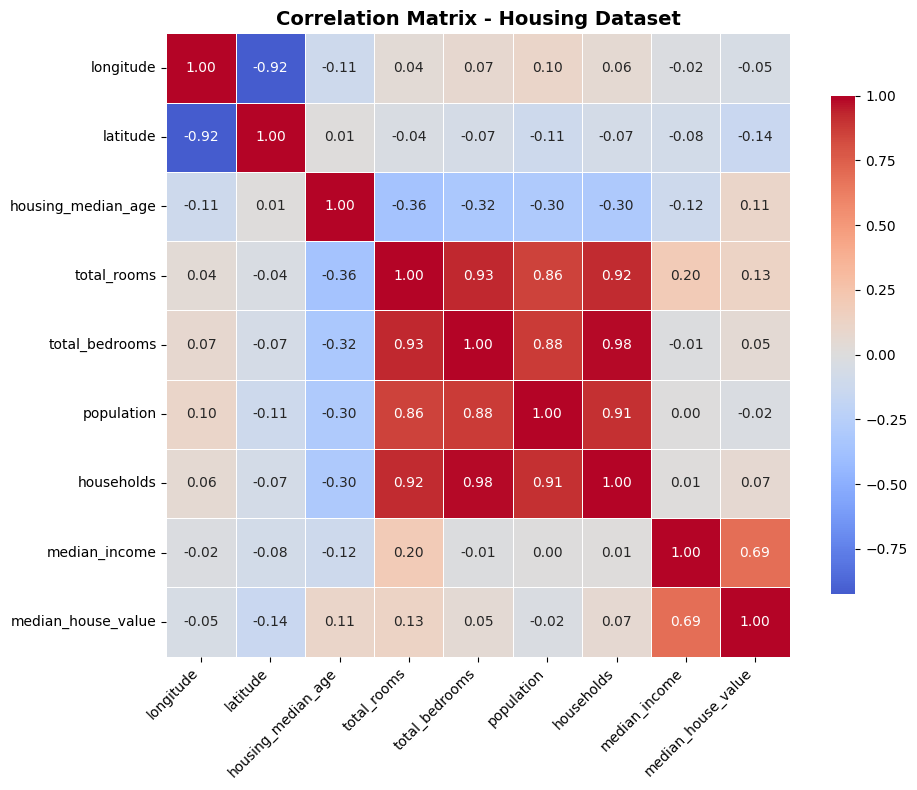

Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -

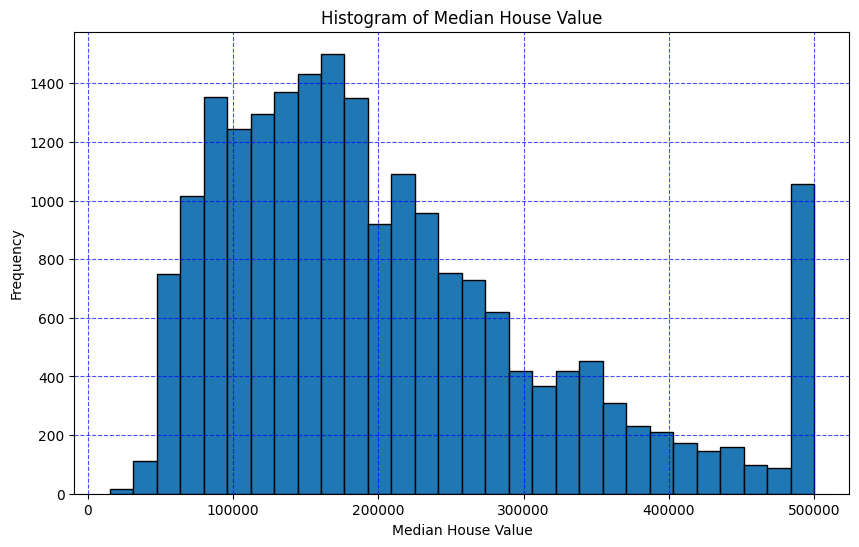

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=30, edgecolor='black')
plt.grid(True, linestyle='--', color='blue', alpha=0.7)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Histogram of Median House Value')
plt.show()
Result: Success | Attempts: 1

Running task 21: [medium] Using the Titanic dataset, make a donut chart showing the passenger count by Pclass. Use wedge width 0.4 and include class labels.


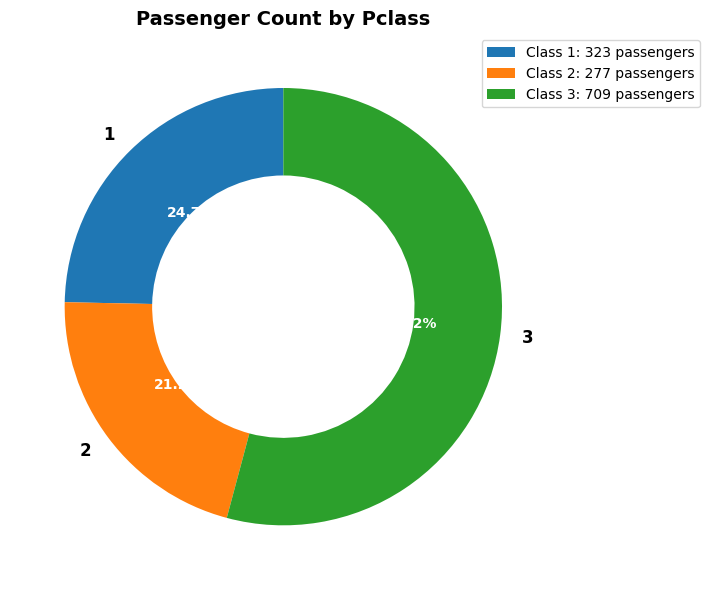

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

# Count passengers by Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()

# Create the donut chart
fig, ax = plt.subplots(figsize=(8, 6))

# Create the pie chart with a donut hole
wedges, texts, autotexts = ax.pie(pclass_counts.values, 
                                    labels=pclass_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    wedgeprops=dict(width=0.4))

# Add title
ax.set_title('Passenger Count by Pclass', fontsize=14, fontweight='bold')

# Customize the labels
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

# Add legend with actual counts
legend_labe

<string>:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


<Figure size 800x800 with 0 Axes>

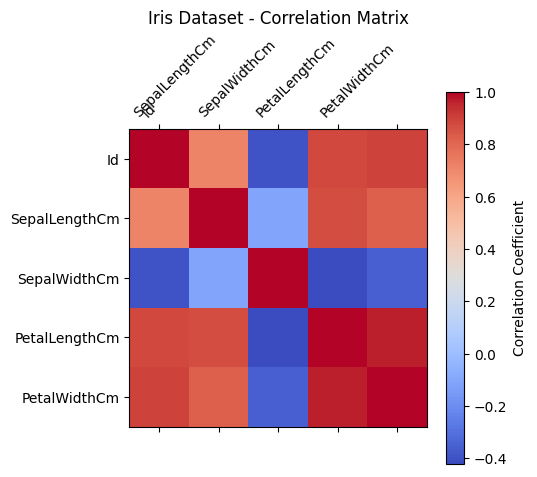

Success on attempt 1

----- Final Code -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Iris dataset
df = pd.read_csv('Iris.csv')

# Select only numeric columns (exclude the Species column)
numeric_features = df.iloc[:, :-1]

# Compute the correlation matrix
correlation_matrix = numeric_features.corr()

# Set figure size to (8, 8)
plt.figure(figsize=(8, 8))

# Plot the correlation matrix using matshow
plt.matshow(correlation_matrix, cmap='coolwarm')

# Add a colorbar
plt.colorbar(label='Correlation Coefficient')

# Add labels for the axes
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Add title
plt.title('Iris Dataset - Correlation Matrix')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()
Result: Success | Attempts: 1

Running task 23: [medium] Using the Iris dataset, 

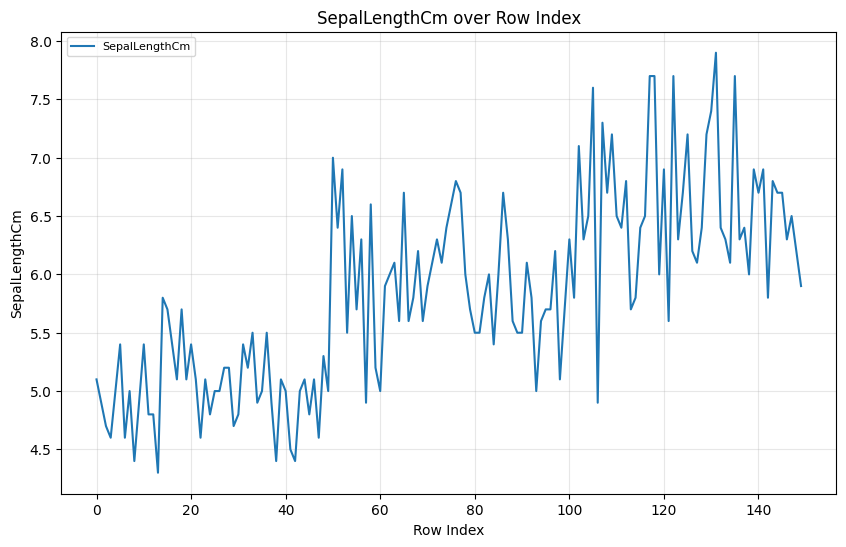

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

# Load the Iris dataset
df = pd.read_csv('Iris.csv')

# Create a plot of SepalLengthCm over the row index
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['SepalLengthCm'], label='SepalLengthCm')
plt.xlabel('Row Index')
plt.ylabel('SepalLengthCm')
plt.title('SepalLengthCm over Row Index')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()
Result: Success | Attempts: 1

Running task 24: [hard] Using the Iris dataset, encode the Species column using LabelEncoder, split the data into train and test sets with ratio 8:2, train a DecisionTreeClassifier, and output accuracy, classification report, and feature importances sorted in descending order.
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00     

<string>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




First 10 predicted survival probabilities:
[0.08790021 0.62975073 0.3329519  0.63747401 0.07058653 0.08686482
 0.18672978 0.11145803 0.30902868 0.5965822 ]
Success on attempt 2

----- Final Code -----
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('titanic.csv')

# The target variable is named '2urvived' based on the actual column names
target_col = '2urvived'

# Handle missing values
# Drop rows where target is missing
df = df.dropna(subset=[target_col])

# For numerical features, fill with median
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if col != target_col:
        df[col].fillna(df[col].median(), inplace=True)

# For categorical features, fill with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df

In [16]:
import json
import pandas as pd

# Load benchmark tasks
with open('benchmarks/prompts.json', 'r') as f:
    benchmarks = json.load(f)['benchmarks']

# Dataset path mapping
dataset_paths = {
    "Iris.csv": "Iris.csv",
    "Titanic.csv": "titanic.csv",
    "housing.csv": "housing.csv"
}

# Run all benchmark tasks with self-healing pipeline
results = []

for task in benchmarks:
    print(f"\nRunning task {task['id']}: [{task['difficulty']}] {task['prompt']}")

    dataset_path = dataset_paths[task['dataset']]
    result = run_pipeline(task['prompt'], dataset_path)

    results.append({
        "id": task['id'],
        "dataset": task['dataset'],
        "difficulty": task['difficulty'],
        "category": task['category'],
        "prompt": task['prompt'],
        "success": result['success'],
        "attempts": result['attempts']
    })

    print(f"Result: {'Success' if result['success'] else 'Failed'} | Attempts: {result['attempts']}")

# Save results to a DataFrame and display summary
df_results = pd.DataFrame(results)
print("\n===== BENCHMARK RESULTS =====")
print(df_results[['id', 'difficulty', 'category', 'success', 'attempts']])
print(f"\nOverall success rate: {df_results['success'].mean()*100:.1f}%")
print(f"Easy success rate: {df_results[df_results['difficulty']=='easy']['success'].mean()*100:.1f}%")
print(f"Medium success rate: {df_results[df_results['difficulty']=='medium']['success'].mean()*100:.1f}%")
print(f"Hard success rate: {df_results[df_results['difficulty']=='hard']['success'].mean()*100:.1f}%")

# Save results to CSV
df_results.to_csv('benchmark_results_haiku.csv', index=False)
print("\nResults saved to benchmark_results_haiku.csv")